# BirdCLEF+ 2026 - Exploratory Data Analysis
## Analysis of train.csv

This notebook explores the training metadata to understand:
- Dataset structure and size
- Species distribution
- Class distribution (birds, frogs, insects, etc.)
- Geographic distribution
- Data sources (iNaturalist vs Xeno-Canto)
- Quality ratings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = '../data/raw/'

## 1. Load and Inspect Data

In [2]:
# Load train.csv
train = pd.read_csv(DATA_PATH + 'train.csv')

print(f"Dataset shape: {train.shape}")
print(f"Number of audio files: {train.shape[0]:,}")
print(f"Number of columns: {train.shape[1]}")

Dataset shape: (35549, 15)
Number of audio files: 35,549
Number of columns: 15


In [3]:
# Display first rows
train.head(10)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
5,1161364,[],[],-22.0843,-47.7327,Guyalna cuta,Guyalna cuta,Insecta,1161364,Carlos Otávio Gussoni,cc-by-nc,0.0,https://static.inaturalist.org/sounds/868369.w...,1161364/iNat868369.ogg,iNat
6,1161364,[],[],-20.9848,-43.7609,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0,https://static.inaturalist.org/sounds/842139.w...,1161364/iNat842139.ogg,iNat
7,1161364,[],[],-19.9674,-43.9895,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0,https://static.inaturalist.org/sounds/840159.m...,1161364/iNat840159.ogg,iNat
8,1161364,[],[],-19.8713,-43.9607,Guyalna cuta,Guyalna cuta,Insecta,1161364,Alexandre S. Michelotto,cc0,0.0,https://static.inaturalist.org/sounds/1264238....,1161364/iNat1264238.ogg,iNat
9,1161364,[],[],-18.8358,-40.7354,Guyalna cuta,Guyalna cuta,Insecta,1161364,Vitor C. Dias Gonçalves,cc-by-nc,0.0,https://static.inaturalist.org/sounds/869958.m...,1161364/iNat869958.ogg,iNat


In [4]:
# Data types and info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 4.1+ MB


In [5]:
# Basic statistics
train.describe()

,latitude,longitude,inat_taxon_id,rating
count,35549.000000,35549.000000,3.554900e+04,35549.000000
mean,-8.166453,-60.744700,8.022132e+04,2.600748
std,20.254421,25.434547,2.422476e+05,2.070471
min,-54.857400,-159.655600,7.000000e+00,0.000000
25%,-23.363600,-75.141700,8.830000e+03,0.000000
50%,-14.882500,-58.130200,1.595700e+04,3.500000
75%,4.642900,-48.733500,1.962700e+04,4.500000
max,69.578000,175.323900,1.595929e+06,5.000000


In [6]:
# Check for missing values
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percentage


## 2. Species Distribution

In [7]:
# Number of unique species
n_species = train['primary_label'].nunique()
print(f"Number of unique species: {n_species}")

Number of unique species: 206


In [8]:
# Samples per species
species_counts = train['primary_label'].value_counts()

print(f"Samples per species:")
print(f"  Min: {species_counts.min()}")
print(f"  Max: {species_counts.max()}")
print(f"  Mean: {species_counts.mean():.1f}")
print(f"  Median: {species_counts.median():.1f}")
print(f"  Std: {species_counts.std():.1f}")

Samples per species:
  Min: 1
  Max: 499
  Mean: 172.6
  Median: 125.0
  Std: 155.4


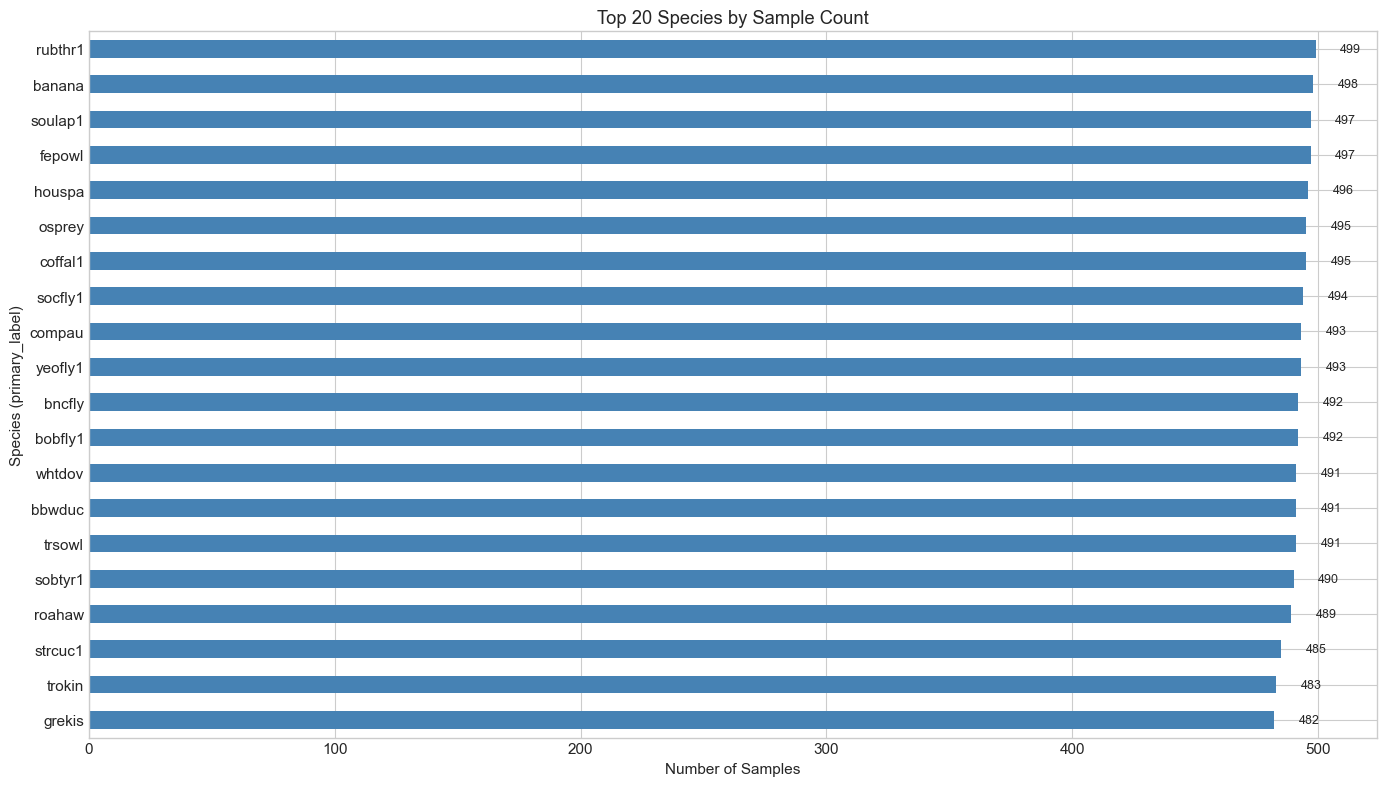

In [9]:
# Top 20 species with most samples
fig, ax = plt.subplots(figsize=(14, 8))
species_counts.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Species (primary_label)')
ax.set_title('Top 20 Species by Sample Count')
ax.invert_yaxis()
for i, v in enumerate(species_counts.head(20)):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

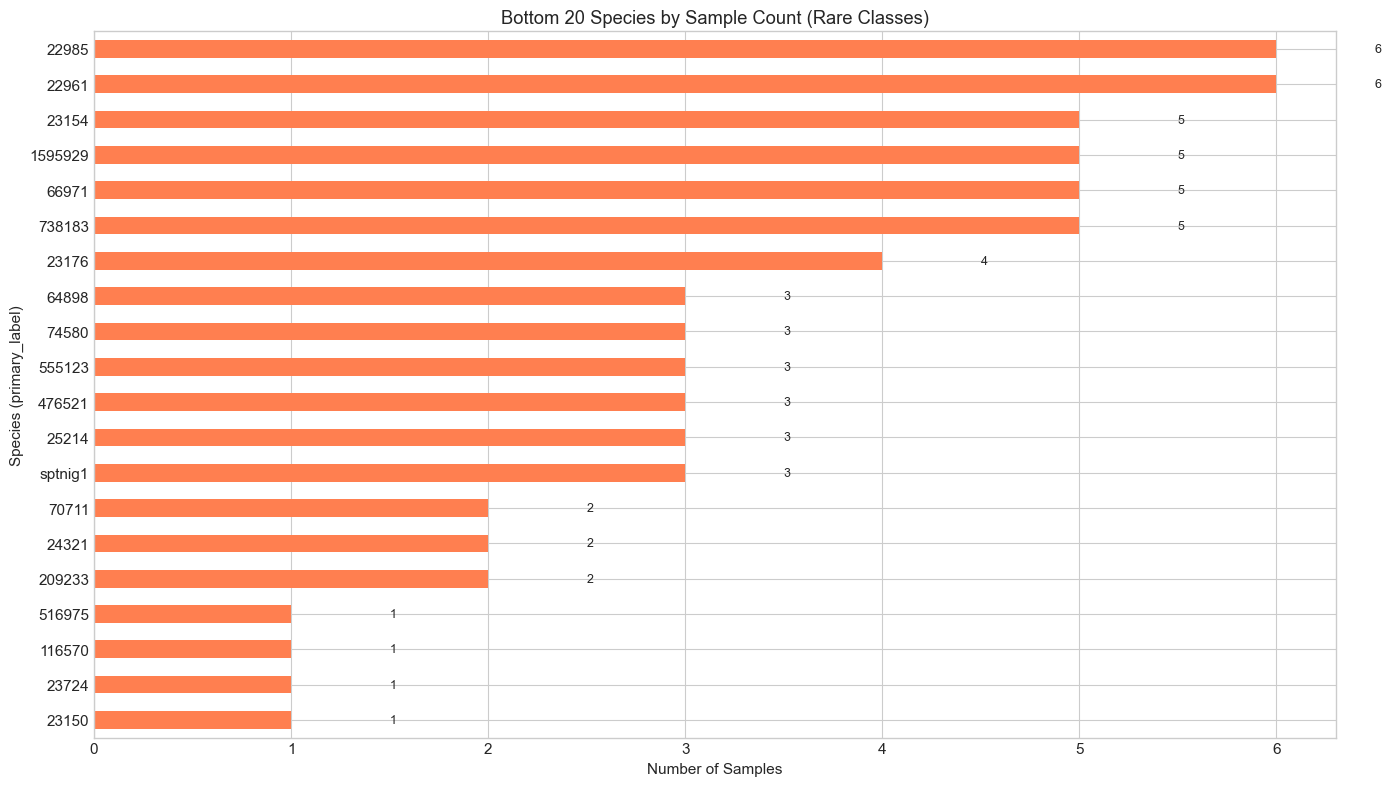

In [10]:
# Bottom 20 species (least samples) - potential rare classes
fig, ax = plt.subplots(figsize=(14, 8))
species_counts.tail(20).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Species (primary_label)')
ax.set_title('Bottom 20 Species by Sample Count (Rare Classes)')
ax.invert_yaxis()
for i, v in enumerate(species_counts.tail(20)):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

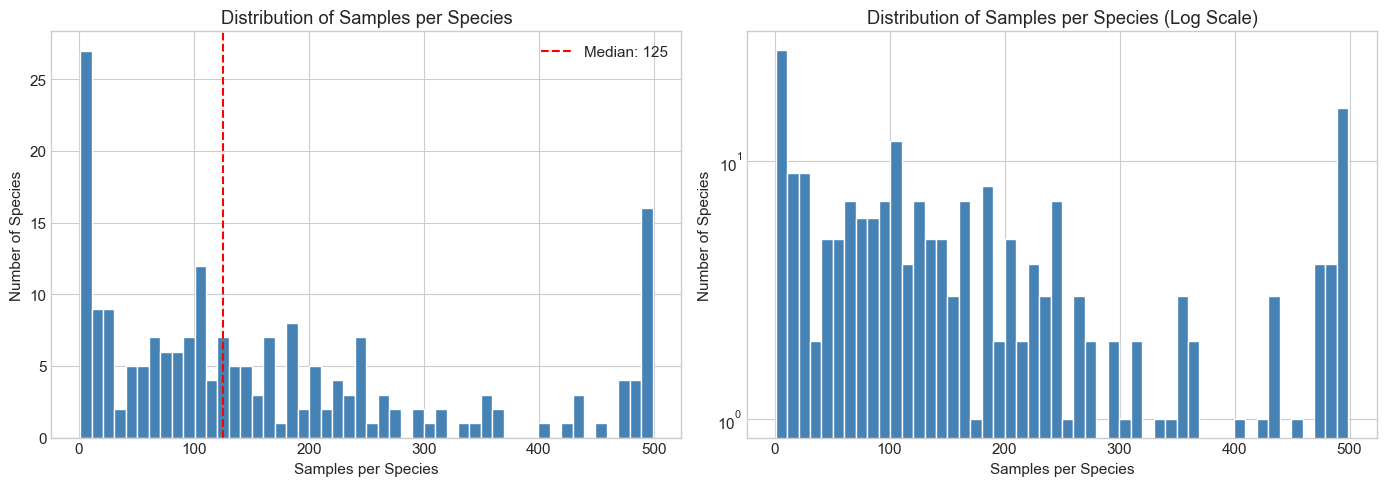

In [11]:
# Distribution of sample counts (histogram)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(species_counts.values, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Samples per Species')
axes[0].set_ylabel('Number of Species')
axes[0].set_title('Distribution of Samples per Species')
axes[0].axvline(species_counts.median(), color='red', linestyle='--', label=f'Median: {species_counts.median():.0f}')
axes[0].legend()

# Log scale
axes[1].hist(species_counts.values, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Samples per Species')
axes[1].set_ylabel('Number of Species')
axes[1].set_title('Distribution of Samples per Species (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [12]:
# Class imbalance analysis
print("Class Imbalance Analysis:")
print(f"  Species with < 10 samples: {(species_counts < 10).sum()}")
print(f"  Species with < 50 samples: {(species_counts < 50).sum()}")
print(f"  Species with < 100 samples: {(species_counts < 100).sum()}")
print(f"  Species with > 500 samples: {(species_counts > 500).sum()}")
print(f"  Species with > 1000 samples: {(species_counts > 1000).sum()}")

Class Imbalance Analysis:
  Species with < 10 samples: 25
  Species with < 50 samples: 52
  Species with < 100 samples: 82
  Species with > 500 samples: 0
  Species with > 1000 samples: 0


## 2.1 Pareto Analysis (80/20 Rule)

Applying the Pareto principle to identify which species cover 80-90% of the training data.

In [13]:
# Calculate cumulative percentage for Pareto analysis
total_samples = len(train)
species_df = pd.DataFrame({
    'species': species_counts.index,
    'count': species_counts.values,
    'percentage': (species_counts.values / total_samples * 100).round(2)
})
species_df['cumulative_pct'] = (species_df['count'].cumsum() / total_samples * 100).round(2)
species_df['rank'] = range(1, len(species_df) + 1)

# Display all species
print(f"Total samples: {total_samples:,}")
print(f"Total species: {len(species_df)}")
print("\nAll species sorted by sample count:")
species_df

Total samples: 35,549
Total species: 206

All species sorted by sample count:


,species,count,percentage,cumulative_pct,rank
0,rubthr1,499,1.40,1.40,1
1,banana,498,1.40,2.80,2
2,soulap1,497,1.40,4.20,3
3,fepowl,497,1.40,5.60,4
4,houspa,496,1.40,7.00,5
...,...,...,...,...,...
201,209233,2,0.01,99.99,202
202,516975,1,0.00,99.99,203
203,116570,1,0.00,99.99,204
204,23724,1,0.00,100.00,205


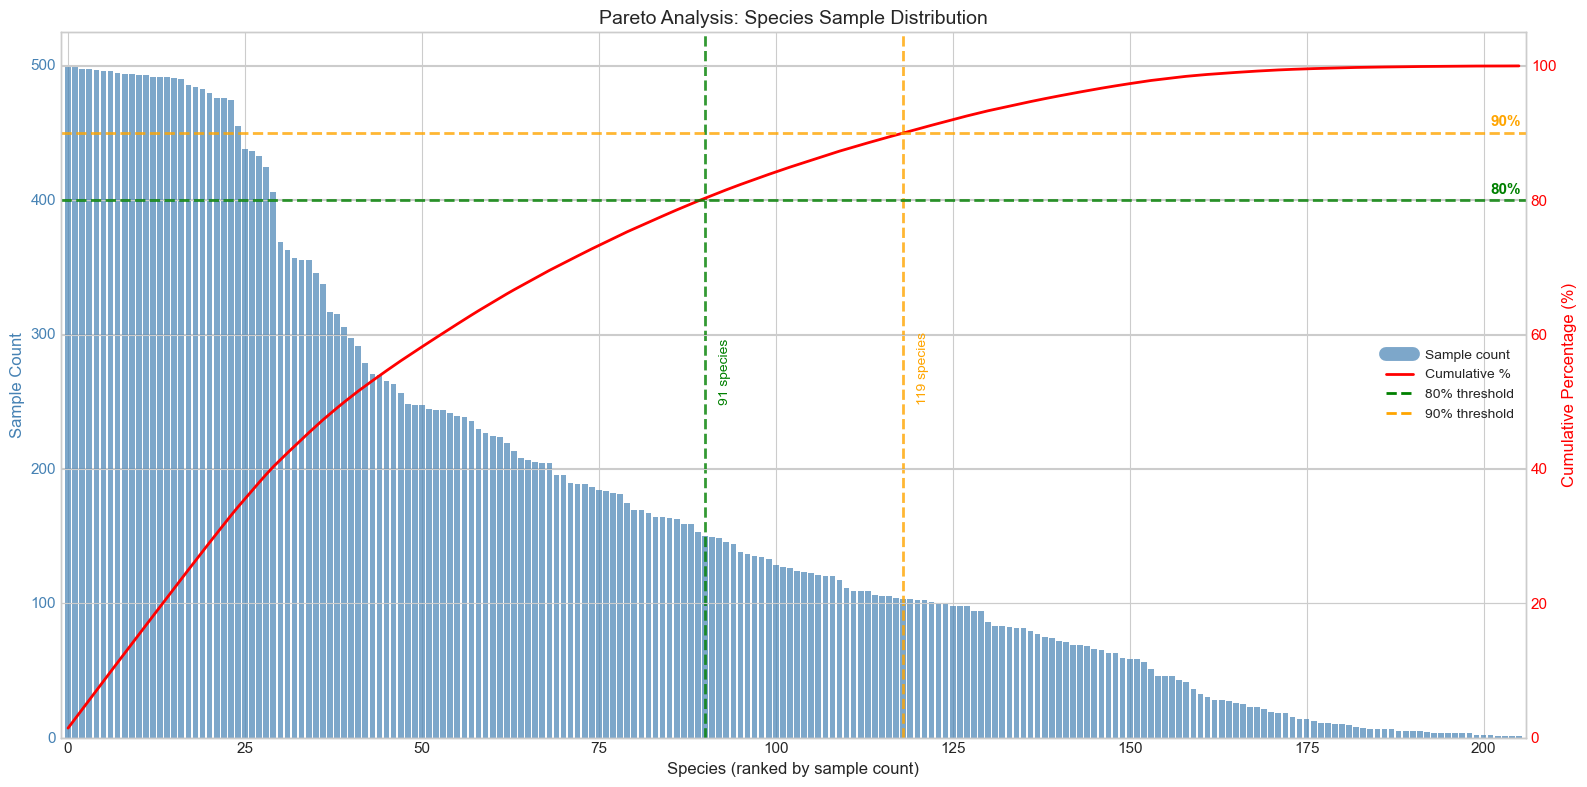

In [14]:
# Pareto chart visualization
fig, ax1 = plt.subplots(figsize=(16, 8))

# Bar chart for counts
bars = ax1.bar(range(len(species_df)), species_df['count'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Species (ranked by sample count)', fontsize=12)
ax1.set_ylabel('Sample Count', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Cumulative line on secondary axis
ax2 = ax1.twinx()
ax2.plot(range(len(species_df)), species_df['cumulative_pct'], color='red', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Add threshold lines
for pct, color, style in [(80, 'green', '--'), (90, 'orange', '--')]:
    ax2.axhline(y=pct, color=color, linestyle=style, linewidth=2, alpha=0.8)
    idx = species_df[species_df['cumulative_pct'] >= pct].index[0]
    ax1.axvline(x=idx, color=color, linestyle=style, linewidth=2, alpha=0.8)
    ax2.text(len(species_df)-5, pct+1, f'{pct}%', color=color, fontsize=11, fontweight='bold')
    ax2.text(idx+2, 50, f'{idx+1} species', color=color, fontsize=10, rotation=90)

ax1.set_title('Pareto Analysis: Species Sample Distribution', fontsize=14)
ax1.set_xlim(-1, len(species_df))
ax2.set_ylim(0, 105)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', lw=10, alpha=0.7, label='Sample count'),
    Line2D([0], [0], color='red', lw=2, label='Cumulative %'),
    Line2D([0], [0], color='green', linestyle='--', lw=2, label='80% threshold'),
    Line2D([0], [0], color='orange', linestyle='--', lw=2, label='90% threshold')
]
ax1.legend(handles=legend_elements, loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Summary at key thresholds
print("PARETO ANALYSIS SUMMARY")
print("=" * 60)
print(f"\n{'Threshold':<12} {'Species':<10} {'% of Species':<15} {'Samples':>10}")
print("-" * 50)

for target_pct in [50, 60, 70, 80, 85, 90, 95]:
    cutoff_idx = species_df[species_df['cumulative_pct'] >= target_pct].index[0]
    n_species = cutoff_idx + 1
    pct_species = n_species / len(species_df) * 100
    samples = species_df.loc[:cutoff_idx, 'count'].sum()
    print(f"{target_pct}%{'':<10} {n_species:<10} {pct_species:<15.1f} {samples:>10,}")

print("\n" + "=" * 60)
print("RECOMMENDATION:")
print("- 80% threshold: 91 species (min 150 samples/species)")
print("- 90% threshold: 119 species (min 103 samples/species)")
print("=" * 60)

PARETO ANALYSIS SUMMARY

Threshold    Species    % of Species       Samples
--------------------------------------------------
50%           41         19.9                18,045
60%           54         26.2                21,409
70%           70         34.0                24,918
80%           91         44.2                28,547
85%           104        50.5                30,314
90%           119        57.8                31,998
95%           139        67.5                33,814

RECOMMENDATION:
- 80% threshold: 91 species (min 150 samples/species)
- 90% threshold: 119 species (min 103 samples/species)


In [16]:
# Species lists for each threshold
cutoff_80_idx = species_df[species_df['cumulative_pct'] >= 80].index[0]
cutoff_90_idx = species_df[species_df['cumulative_pct'] >= 90].index[0]

species_keep_80 = species_df.loc[:cutoff_80_idx, 'species'].tolist()
species_keep_90 = species_df.loc[:cutoff_90_idx, 'species'].tolist()
species_exclude_80 = species_df.loc[cutoff_80_idx+1:, 'species'].tolist()
species_exclude_90 = species_df.loc[cutoff_90_idx+1:, 'species'].tolist()

print(f"80% Threshold:")
print(f"  - Keep: {len(species_keep_80)} species")
print(f"  - Exclude: {len(species_exclude_80)} species")
print(f"  - Min samples in kept species: {species_df.loc[cutoff_80_idx, 'count']}")

print(f"\n90% Threshold:")
print(f"  - Keep: {len(species_keep_90)} species")
print(f"  - Exclude: {len(species_exclude_90)} species")
print(f"  - Min samples in kept species: {species_df.loc[cutoff_90_idx, 'count']}")

# Save species lists
pd.DataFrame({'species': species_keep_80}).to_csv('../reports/species_keep_80pct.csv', index=False)
pd.DataFrame({'species': species_keep_90}).to_csv('../reports/species_keep_90pct.csv', index=False)
species_df.to_csv('../reports/all_species_distribution.csv', index=False)
print("\nSpecies lists saved to reports/")

80% Threshold:
  - Keep: 91 species
  - Exclude: 115 species
  - Min samples in kept species: 150

90% Threshold:
  - Keep: 119 species
  - Exclude: 87 species
  - Min samples in kept species: 103

Species lists saved to reports/


In [17]:
# Show excluded species at 90% threshold
print("EXCLUDED SPECIES AT 90% THRESHOLD")
print("(These species have < 103 samples each)")
print("=" * 50)
excluded_df = species_df.loc[cutoff_90_idx+1:][['species', 'count', 'percentage']]
print(excluded_df.to_string(index=False))

EXCLUDED SPECIES AT 90% THRESHOLD
(These species have < 103 samples each)
species  count  percentage
scther1    103        0.29
ragmac1    102        0.29
horscr1    102        0.29
 shshaw    101        0.28
rivwar1    100        0.28
chacha1     99        0.28
ruftof1     98        0.28
ruftho1     98        0.28
swthum1     98        0.28
smbtin1     94        0.26
grhtan1     94        0.26
ruther1     86        0.24
whwpic1     83        0.23
 fotfly     83        0.23
yehcar1     82        0.23
crebec1     81        0.23
orbtro3     81        0.23
fabwre1     79        0.22
purjay1     77        0.22
whbant2     75        0.21
magtan2     74        0.21
grepot1     72        0.20
blttit1     71        0.20
sabspa1     69        0.19
palhor3     69        0.19
pluibi1     68        0.19
ficman1     66        0.19
hyamac1     65        0.18
  22973     63        0.18
magant1     63        0.18
whlspi1     59        0.17
blchaw1     58        0.16
rufcas2     58        0.16
bcwfin2 

### 2.1.1 Geographic Distribution of 80% Pareto Species

In [18]:
# Geographic distribution: 80% Pareto species vs excluded
species_keep_80 = species_df.loc[:cutoff_80_idx, 'species'].tolist()
train_80 = train[train['primary_label'].isin(species_keep_80)]
train_excluded = train[~train['primary_label'].isin(species_keep_80)]

# Define Pantanal region (if not already defined)
pantanal_lat = [-21.6, -16.5]
pantanal_lon = [-57.6, -55.9]

# Check Pantanal coverage for all species
in_pantanal = (
    (train['latitude'] >= pantanal_lat[0]) & 
    (train['latitude'] <= pantanal_lat[1]) &
    (train['longitude'] >= pantanal_lon[0]) & 
    (train['longitude'] <= pantanal_lon[1])
)

# Check Pantanal coverage for 80% species
in_pantanal_80 = (
    (train_80['latitude'] >= pantanal_lat[0]) & 
    (train_80['latitude'] <= pantanal_lat[1]) &
    (train_80['longitude'] >= pantanal_lon[0]) & 
    (train_80['longitude'] <= pantanal_lon[1])
)

print("PANTANAL REGION COVERAGE")
print("=" * 50)
print(f"All species in Pantanal: {in_pantanal.sum():,} samples")
print(f"80% Pareto species in Pantanal: {in_pantanal_80.sum():,} samples")
print(f"Coverage retained: {in_pantanal_80.sum()/in_pantanal.sum()*100:.1f}%")
print(f"\nWARNING: 80% threshold excludes {100 - in_pantanal_80.sum()/in_pantanal.sum()*100:.1f}% of Pantanal samples!")

PANTANAL REGION COVERAGE
All species in Pantanal: 847 samples
80% Pareto species in Pantanal: 398 samples
Coverage retained: 47.0%



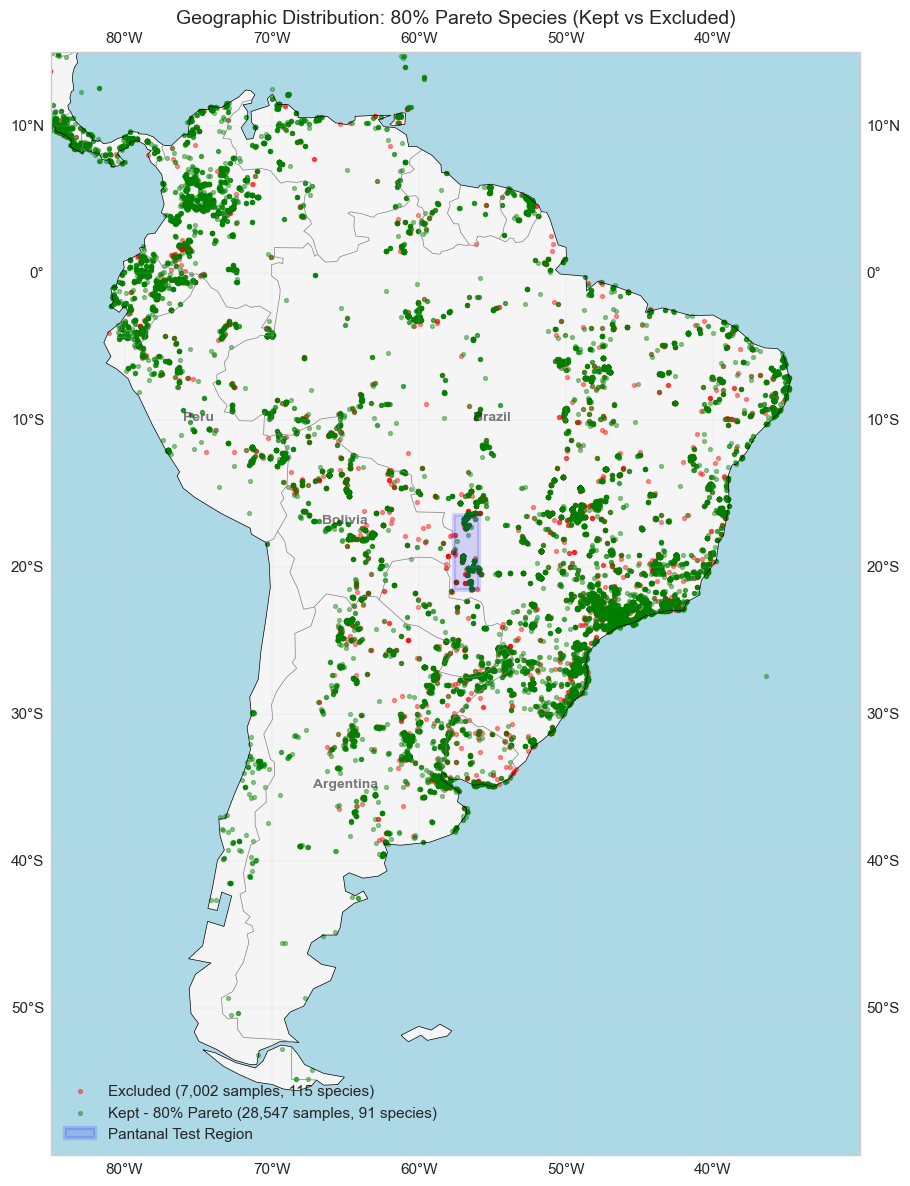

In [19]:
# Geographic map: Kept vs Excluded species
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.STATES, linewidth=0.2, edgecolor='lightgray')

# Plot excluded first (background)
ax.scatter(train_excluded['longitude'], train_excluded['latitude'], 
           c='red', s=8, alpha=0.4, transform=ccrs.PlateCarree(), 
           label=f'Excluded ({len(train_excluded):,} samples, {train_excluded["primary_label"].nunique()} species)')

# Plot kept on top
ax.scatter(train_80['longitude'], train_80['latitude'], 
           c='green', s=8, alpha=0.4, transform=ccrs.PlateCarree(),
           label=f'Kept - 80% Pareto ({len(train_80):,} samples, {len(species_keep_80)} species)')

# Pantanal box
rect = Rectangle((pantanal_lon[0], pantanal_lat[0]), 
                  pantanal_lon[1] - pantanal_lon[0], 
                  pantanal_lat[1] - pantanal_lat[0],
                  linewidth=3, edgecolor='blue', facecolor='blue', alpha=0.15,
                  transform=ccrs.PlateCarree(), label='Pantanal Test Region')
ax.add_patch(rect)

# Country labels
for country, (lon, lat) in [('Brazil', (-55, -10)), ('Argentina', (-65, -35)), 
                             ('Peru', (-75, -10)), ('Bolivia', (-65, -17))]:
    ax.text(lon, lat, country, fontsize=10, fontweight='bold', 
            ha='center', transform=ccrs.PlateCarree(), alpha=0.6)

ax.set_title('Geographic Distribution: 80% Pareto Species (Kept vs Excluded)', fontsize=14)
ax.legend(loc='lower left', fontsize=11, framealpha=0.9)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.savefig('../reports/figures/geographic_pareto_80_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Class Distribution (Taxonomic Groups)

In [20]:
# Distribution by class_name (Aves, Amphibia, etc.)
class_counts = train['class_name'].value_counts()
print("Samples by taxonomic class:")
print(class_counts)

Samples by taxonomic class:
class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1
Name: count, dtype: int64


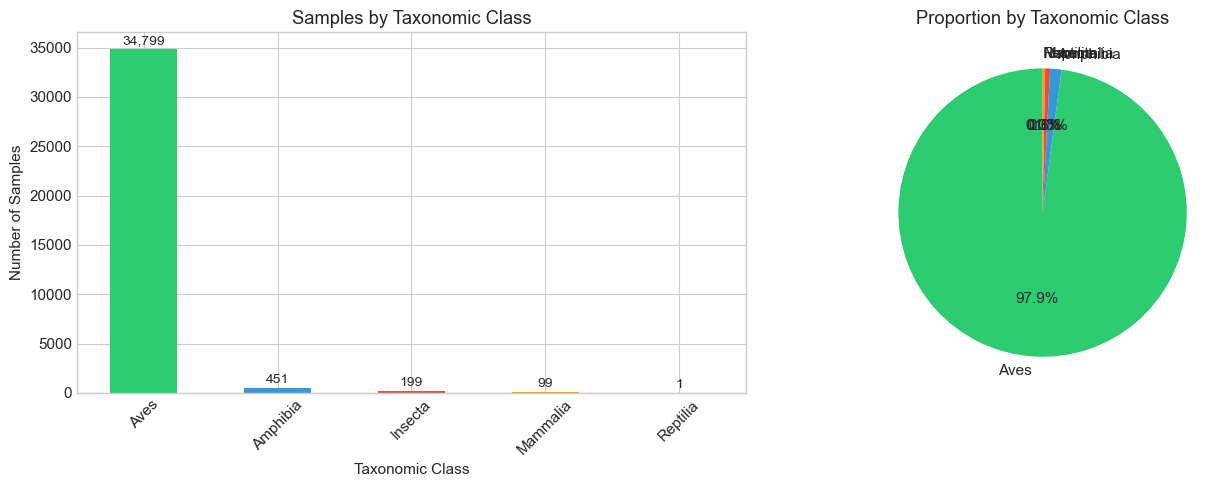

In [21]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
class_counts.plot(kind='bar', ax=axes[0], color=colors[:len(class_counts)])
axes[0].set_xlabel('Taxonomic Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Samples by Taxonomic Class')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors[:len(class_counts)], startangle=90)
axes[1].set_title('Proportion by Taxonomic Class')

plt.tight_layout()
plt.show()

In [22]:
# Number of unique species per class
species_per_class = train.groupby('class_name')['primary_label'].nunique().sort_values(ascending=False)
print("Number of unique species per class:")
print(species_per_class)

Number of unique species per class:
class_name
Aves        162
Amphibia     32
Mammalia      8
Insecta       3
Reptilia      1
Name: primary_label, dtype: int64


## 4. Data Source Analysis

In [23]:
# Distribution by collection source (iNat vs XC)
collection_counts = train['collection'].value_counts()
print("Samples by data source:")
print(collection_counts)
print(f"\nPercentages:")
print((collection_counts / len(train) * 100).round(2))

Samples by data source:
collection
XC      23043
iNat    12506
Name: count, dtype: int64

Percentages:
collection
XC      64.82
iNat    35.18
Name: count, dtype: float64


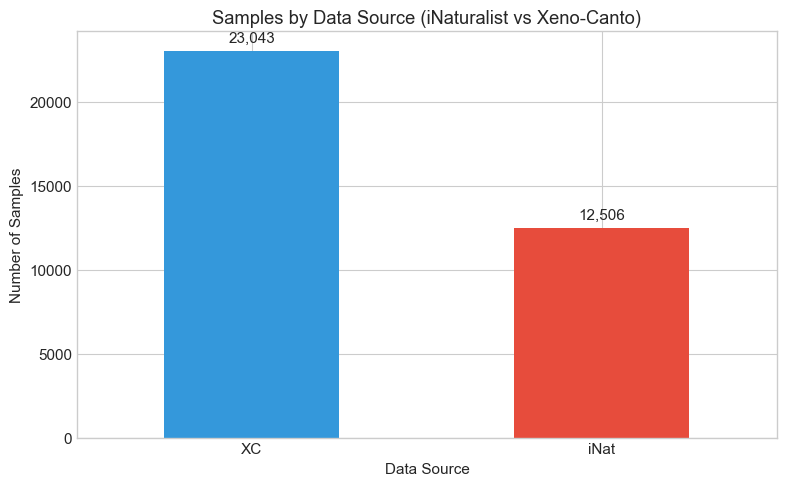

In [24]:
# Visualize collection distribution
fig, ax = plt.subplots(figsize=(8, 5))
collection_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_xlabel('Data Source')
ax.set_ylabel('Number of Samples')
ax.set_title('Samples by Data Source (iNaturalist vs Xeno-Canto)')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(collection_counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
# Source distribution by taxonomic class
source_by_class = pd.crosstab(train['class_name'], train['collection'])
print("Source distribution by taxonomic class:")
print(source_by_class)

Source distribution by taxonomic class:
collection     XC   iNat
class_name              
Amphibia       58    393
Aves        22952  11847
Insecta         0    199
Mammalia       33     66
Reptilia        0      1


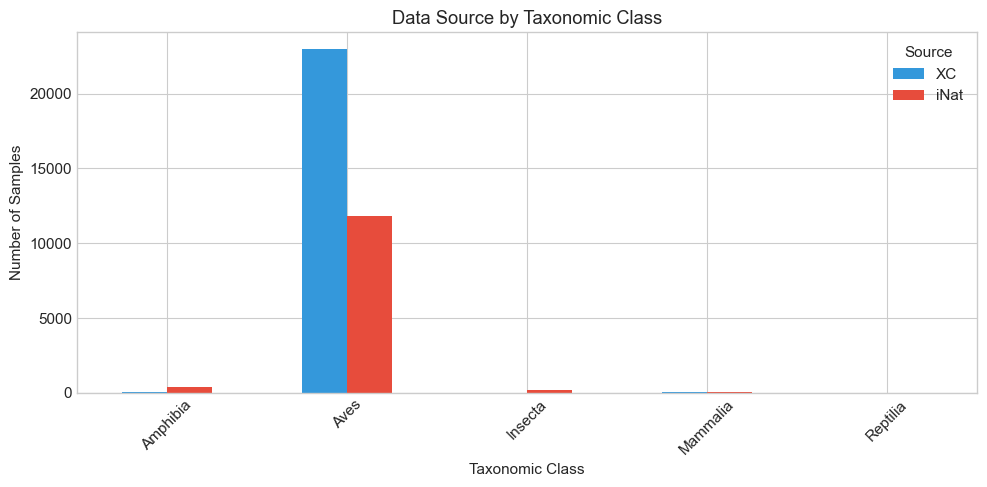

In [26]:
# Visualize source by class
source_by_class.plot(kind='bar', figsize=(10, 5), color=['#3498db', '#e74c3c'])
plt.xlabel('Taxonomic Class')
plt.ylabel('Number of Samples')
plt.title('Data Source by Taxonomic Class')
plt.legend(title='Source')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Geographic Distribution (with Country Boundaries)

In [27]:
# Check for missing coordinates
print(f"Missing latitude: {train['latitude'].isnull().sum()}")
print(f"Missing longitude: {train['longitude'].isnull().sum()}")

# Coordinate statistics
print(f"\nLatitude range: {train['latitude'].min():.2f} to {train['latitude'].max():.2f}")
print(f"Longitude range: {train['longitude'].min():.2f} to {train['longitude'].max():.2f}")

# Pantanal region
pantanal_lat = [-21.6, -16.5]
pantanal_lon = [-57.6, -55.9]

Missing latitude: 0
Missing longitude: 0

Latitude range: -54.86 to 69.58
Longitude range: -159.66 to 175.32


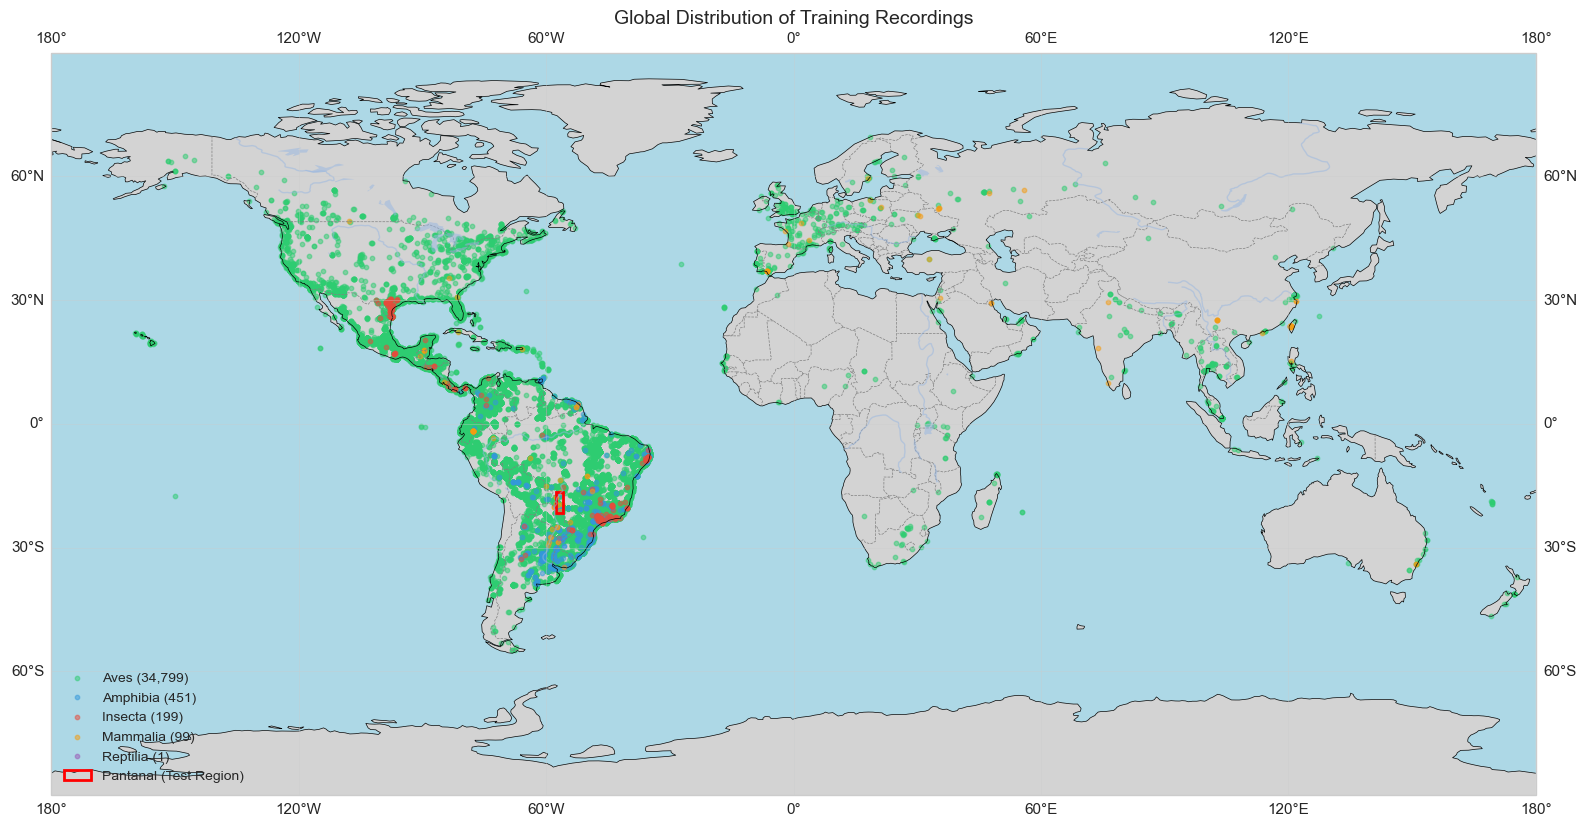

In [28]:
# World map with all recording locations
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, alpha=0.5)

# Plot recording locations colored by taxonomic class
class_colors = {'Aves': '#2ecc71', 'Amphibia': '#3498db', 'Insecta': '#e74c3c', 
                'Mammalia': '#f39c12', 'Reptilia': '#9b59b6'}

for class_name, color in class_colors.items():
    subset = train[train['class_name'] == class_name]
    ax.scatter(subset['longitude'], subset['latitude'], 
               c=color, s=10, alpha=0.5, label=f'{class_name} ({len(subset):,})',
               transform=ccrs.PlateCarree())

# Highlight Pantanal region
from matplotlib.patches import Rectangle
rect = Rectangle((pantanal_lon[0], pantanal_lat[0]), 
                  pantanal_lon[1] - pantanal_lon[0], 
                  pantanal_lat[1] - pantanal_lat[0],
                  linewidth=2, edgecolor='red', facecolor='none',
                  transform=ccrs.PlateCarree(), label='Pantanal (Test Region)')
ax.add_patch(rect)

ax.set_global()
ax.set_title('Global Distribution of Training Recordings', fontsize=14)
ax.legend(loc='lower left', fontsize=10)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

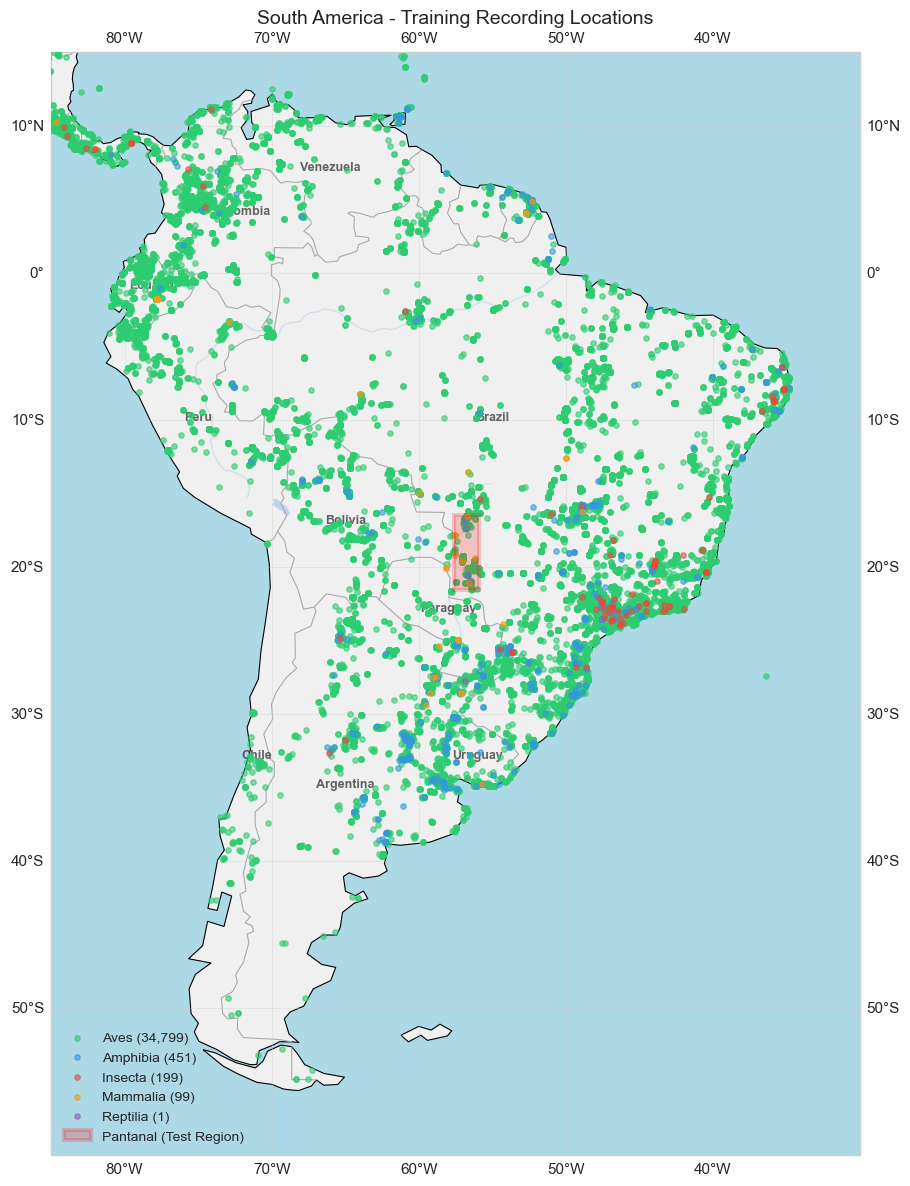

In [29]:
# South America focus (where most data is)
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent to South America
ax.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.8, edgecolor='darkgray')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, alpha=0.3)

# Add country names
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='lightgray')

# Plot recording locations
for class_name, color in class_colors.items():
    subset = train[train['class_name'] == class_name]
    ax.scatter(subset['longitude'], subset['latitude'], 
               c=color, s=15, alpha=0.6, label=f'{class_name} ({len(subset):,})',
               transform=ccrs.PlateCarree(), zorder=5)

# Highlight Pantanal region
rect = Rectangle((pantanal_lon[0], pantanal_lat[0]), 
                  pantanal_lon[1] - pantanal_lon[0], 
                  pantanal_lat[1] - pantanal_lat[0],
                  linewidth=3, edgecolor='red', facecolor='red', alpha=0.2,
                  transform=ccrs.PlateCarree(), label='Pantanal (Test Region)', zorder=10)
ax.add_patch(rect)

# Add country labels
countries = {
    'Brazil': (-55, -10),
    'Argentina': (-65, -35),
    'Peru': (-75, -10),
    'Colombia': (-72, 4),
    'Bolivia': (-65, -17),
    'Paraguay': (-58, -23),
    'Chile': (-71, -33),
    'Ecuador': (-78, -1),
    'Venezuela': (-66, 7),
    'Uruguay': (-56, -33)
}
for country, (lon, lat) in countries.items():
    ax.text(lon, lat, country, fontsize=9, fontweight='bold', 
            ha='center', transform=ccrs.PlateCarree(), alpha=0.7)

ax.set_title('South America - Training Recording Locations', fontsize=14)
ax.legend(loc='lower left', fontsize=10)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

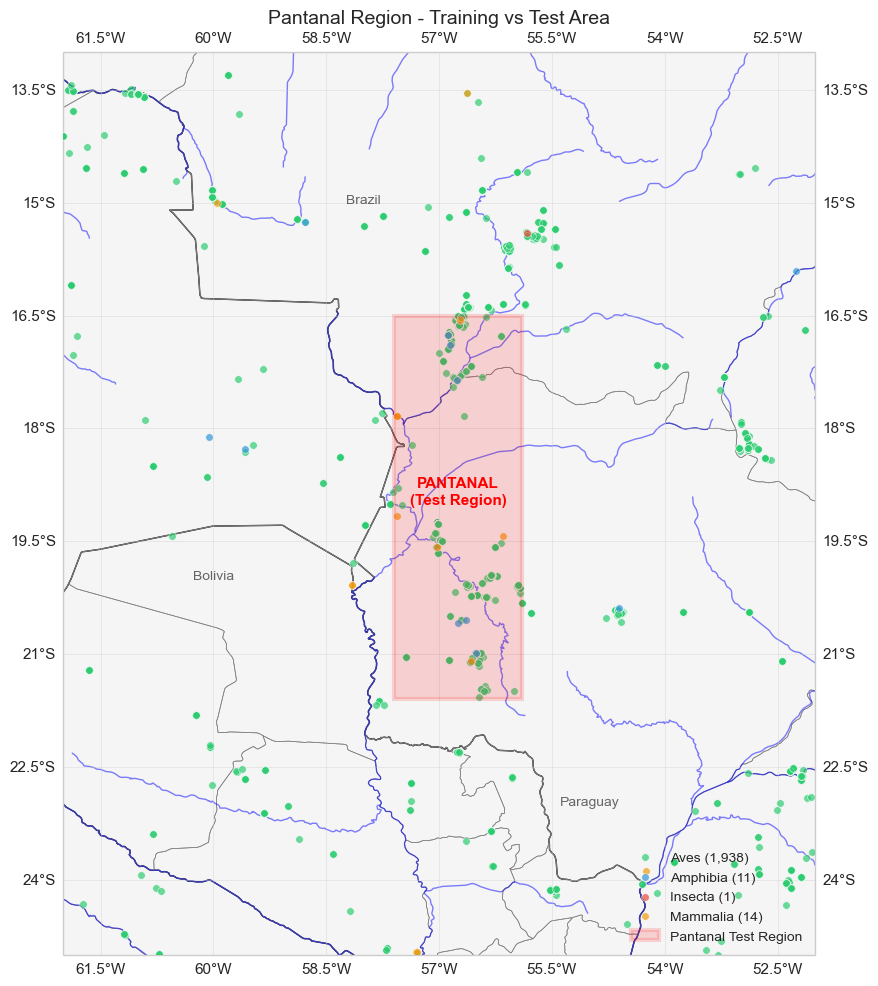

In [30]:
# Pantanal region zoom
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Set extent to Pantanal area with buffer
ax.set_extent([-62, -52, -25, -13], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.RIVERS, alpha=0.5, edgecolor='blue')

# Plot all recordings in this region
mask = (train['latitude'] >= -25) & (train['latitude'] <= -13) & \
       (train['longitude'] >= -62) & (train['longitude'] <= -52)
subset = train[mask]

for class_name, color in class_colors.items():
    class_subset = subset[subset['class_name'] == class_name]
    if len(class_subset) > 0:
        ax.scatter(class_subset['longitude'], class_subset['latitude'], 
                   c=color, s=30, alpha=0.7, label=f'{class_name} ({len(class_subset):,})',
                   transform=ccrs.PlateCarree(), zorder=5, edgecolors='white', linewidth=0.5)

# Highlight exact Pantanal test region
rect = Rectangle((pantanal_lon[0], pantanal_lat[0]), 
                  pantanal_lon[1] - pantanal_lon[0], 
                  pantanal_lat[1] - pantanal_lat[0],
                  linewidth=3, edgecolor='red', facecolor='red', alpha=0.15,
                  transform=ccrs.PlateCarree(), label='Pantanal Test Region', zorder=10)
ax.add_patch(rect)

# Add labels
ax.text(-56.75, -19, 'PANTANAL\n(Test Region)', fontsize=11, fontweight='bold', 
        ha='center', color='red', transform=ccrs.PlateCarree())
ax.text(-55, -23, 'Paraguay', fontsize=10, ha='center', transform=ccrs.PlateCarree(), alpha=0.7)
ax.text(-58, -15, 'Brazil', fontsize=10, ha='center', transform=ccrs.PlateCarree(), alpha=0.7)
ax.text(-60, -20, 'Bolivia', fontsize=10, ha='center', transform=ccrs.PlateCarree(), alpha=0.7)

ax.set_title('Pantanal Region - Training vs Test Area', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [31]:
# How many recordings are within the Pantanal region?
in_pantanal = (
    (train['latitude'] >= pantanal_lat[0]) & 
    (train['latitude'] <= pantanal_lat[1]) &
    (train['longitude'] >= pantanal_lon[0]) & 
    (train['longitude'] <= pantanal_lon[1])
)
print(f"Recordings within Pantanal region: {in_pantanal.sum():,} ({in_pantanal.sum()/len(train)*100:.1f}%)")
print(f"Recordings outside Pantanal region: {(~in_pantanal).sum():,} ({(~in_pantanal).sum()/len(train)*100:.1f}%)")

Recordings within Pantanal region: 847 (2.4%)
Recordings outside Pantanal region: 34,702 (97.6%)


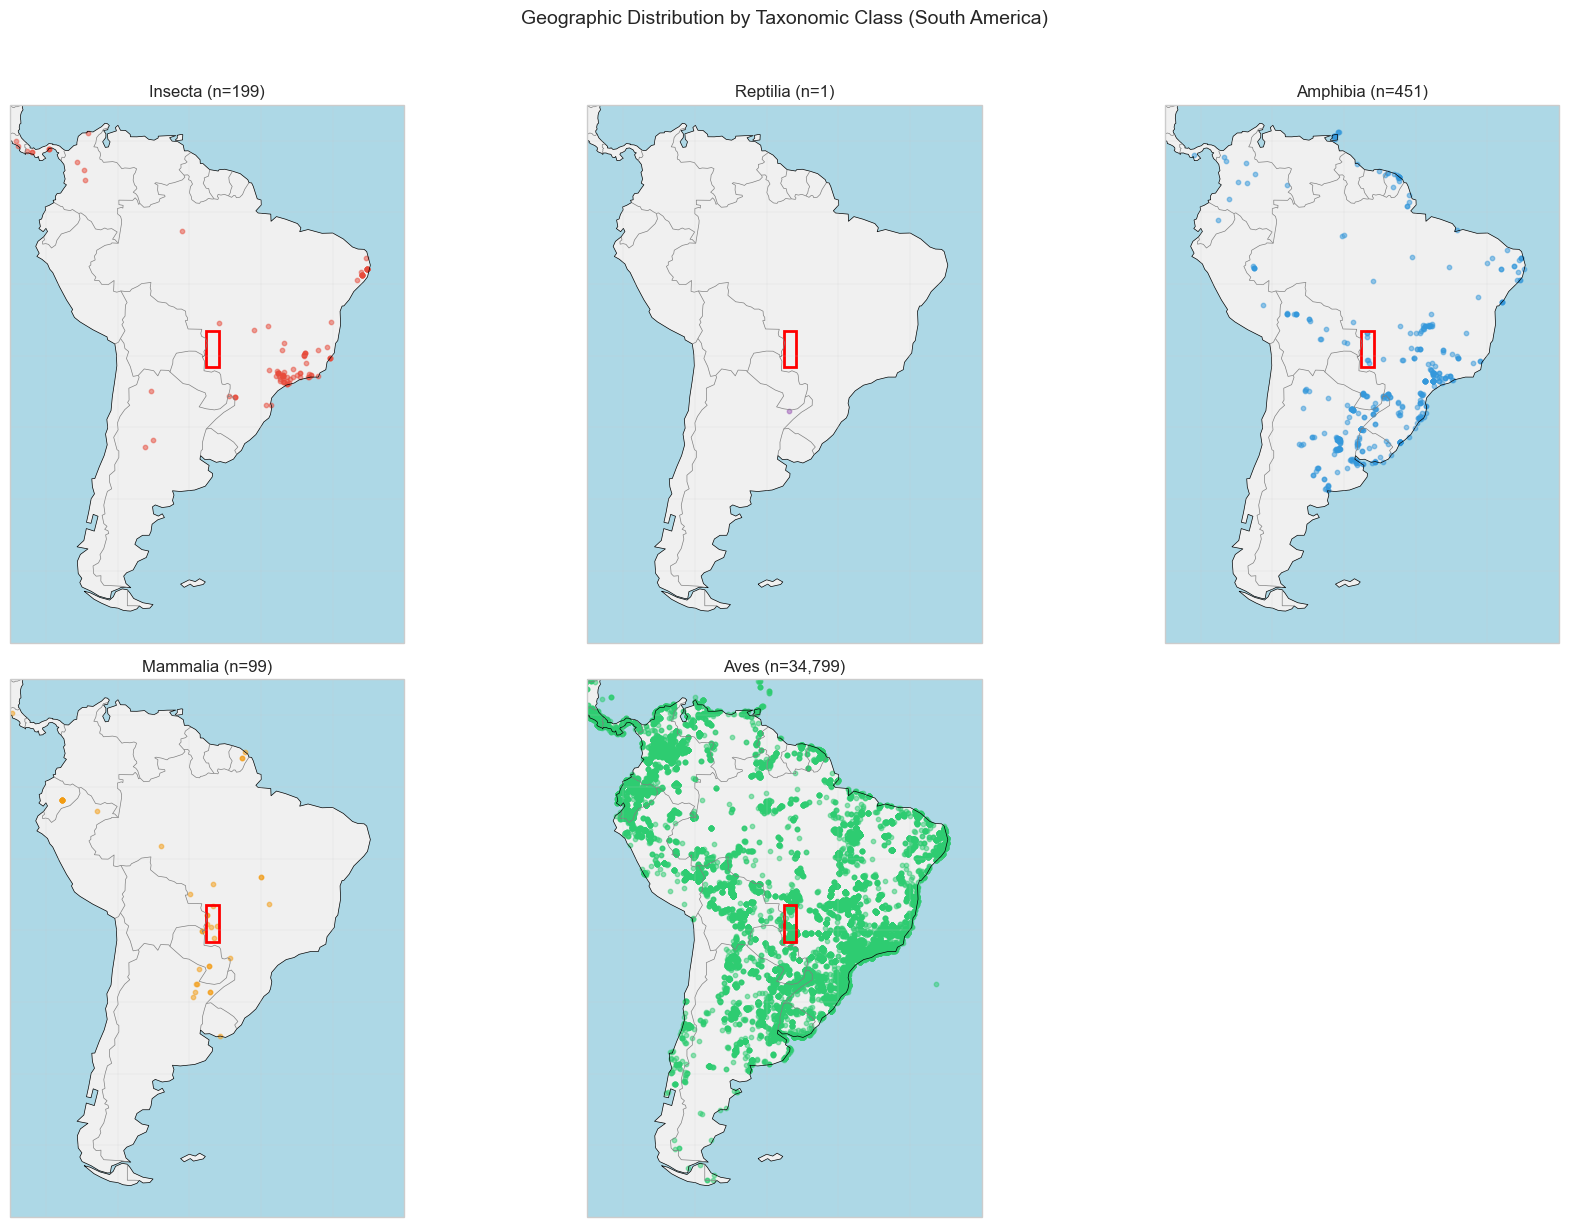

In [32]:
# Geographic distribution by taxonomic class (with country boundaries)
fig = plt.figure(figsize=(18, 12))

for idx, class_name in enumerate(train['class_name'].unique()):
    ax = fig.add_subplot(2, 3, idx + 1, projection=ccrs.PlateCarree())
    ax.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5, edgecolor='gray')
    
    # Plot recordings
    subset = train[train['class_name'] == class_name]
    ax.scatter(subset['longitude'], subset['latitude'], 
               c=class_colors.get(class_name, 'blue'), s=10, alpha=0.5,
               transform=ccrs.PlateCarree())
    
    # Add Pantanal box
    rect = Rectangle((pantanal_lon[0], pantanal_lat[0]), 
                      pantanal_lon[1] - pantanal_lon[0], 
                      pantanal_lat[1] - pantanal_lat[0],
                      linewidth=2, edgecolor='red', facecolor='none',
                      transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    
    ax.set_title(f'{class_name} (n={len(subset):,})', fontsize=12)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

plt.suptitle('Geographic Distribution by Taxonomic Class (South America)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Quality Ratings

In [33]:
# Rating distribution
print(f"Rating statistics:")
print(train['rating'].describe())
print(f"\nRating value counts:")
print(train['rating'].value_counts().sort_index())

Rating statistics:
count    35549.000000
mean         2.600748
std          2.070471
min          0.000000
25%          0.000000
50%          3.500000
75%          4.500000
max          5.000000
Name: rating, dtype: float64

Rating value counts:
rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845
Name: count, dtype: int64


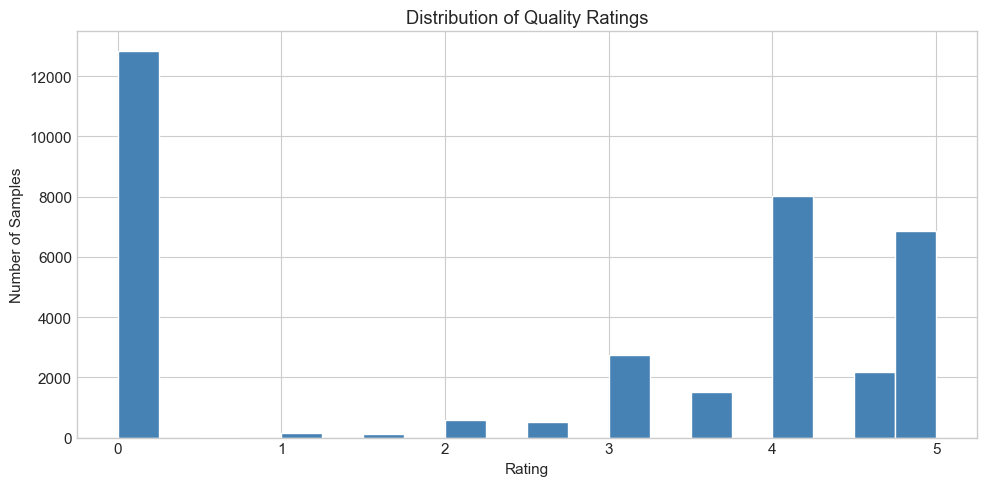

In [34]:
# Rating distribution histogram
fig, ax = plt.subplots(figsize=(10, 5))
train['rating'].hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Quality Ratings')
plt.tight_layout()
plt.show()

In [35]:
# Rating by source
rating_by_source = train.groupby('collection')['rating'].describe()
print("Rating statistics by data source:")
print(rating_by_source)

Rating statistics by data source:
              count      mean       std  min  25%  50%  75%  max
collection                                                      
XC          23043.0  4.012238  0.974705  0.0  3.5  4.0  5.0  5.0
iNat        12506.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0


## 7. License Distribution

In [36]:
# License types
license_counts = train['license'].value_counts()
print("License distribution:")
print(license_counts)

License distribution:
license
by-nc-sa       22843
cc-by-nc        9651
cc-by           2202
cc0              290
cc-by-nc-sa      249
by-sa            200
cc-by-sa         114
Name: count, dtype: int64


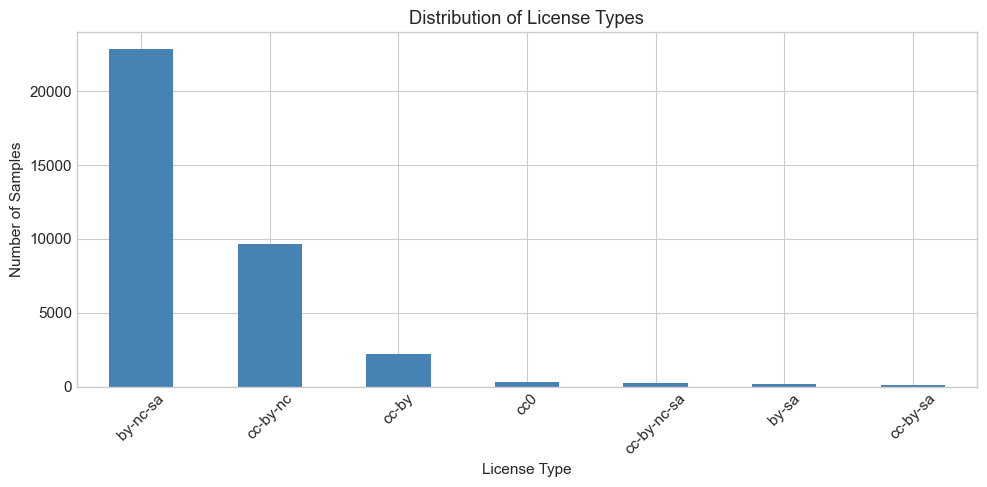

In [37]:
# Visualize license distribution
fig, ax = plt.subplots(figsize=(10, 5))
license_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('License Type')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of License Types')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Secondary Labels Analysis

In [38]:
# Check secondary labels
train['has_secondary'] = train['secondary_labels'].apply(lambda x: x != '[]')
print(f"Samples with secondary labels: {train['has_secondary'].sum():,} ({train['has_secondary'].sum()/len(train)*100:.1f}%)")
print(f"Samples without secondary labels: {(~train['has_secondary']).sum():,}")

Samples with secondary labels: 4,372 (12.3%)
Samples without secondary labels: 31,177


In [39]:
# Show some examples with secondary labels
if train['has_secondary'].sum() > 0:
    print("Examples with secondary labels:")
    display(train[train['has_secondary']][['primary_label', 'secondary_labels', 'common_name']].head(10))

Examples with secondary labels:


,primary_label,secondary_labels,common_name
138,22973,['compau'],Whistling Grass Frog
169,23158,['saffin'],Pale-legged Weeping Frog
239,24279,"['326272', '67107']",Lesser Snouted Tree Frog
240,24279,"['326272', '67107']",Lesser Snouted Tree Frog
241,24279,['326272'],Lesser Snouted Tree Frog
264,24287,['roahaw'],Brown-bordered Snouted Tree Frog
462,25092,"['picpig2', 'rufhor2', '23158', 'saffin']",Two-colored oval frog
507,326272,"['25092', '24279']",Weeping Frog
508,326272,"['25092', '24279']",Weeping Frog
509,326272,"['25092', '67107', '24279']",Weeping Frog


## 9. Summary Statistics

In [40]:
# Create summary table
summary = {
    'Total samples': len(train),
    'Unique species': train['primary_label'].nunique(),
    'Taxonomic classes': train['class_name'].nunique(),
    'Min samples/species': species_counts.min(),
    'Max samples/species': species_counts.max(),
    'Mean samples/species': round(species_counts.mean(), 1),
    'Median samples/species': species_counts.median(),
    'iNaturalist samples': collection_counts.get('iNat', 0),
    'Xeno-Canto samples': collection_counts.get('XC', 0),
    'In Pantanal region': in_pantanal.sum(),
    'Outside Pantanal': (~in_pantanal).sum()
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df

,Value
Total samples,35549.0
Unique species,206.0
Taxonomic classes,5.0
Min samples/species,1.0
Max samples/species,499.0
Mean samples/species,172.6
Median samples/species,125.0
iNaturalist samples,12506.0
Xeno-Canto samples,23043.0
In Pantanal region,847.0


In [41]:
# Save summary to file
summary_df.to_csv('../reports/train_summary.csv')
print("Summary saved to reports/train_summary.csv")

Summary saved to reports/train_summary.csv


## Key Findings

### Dataset Overview
- **Total samples:** 35,549
- **Species:** 206 unique classes
- **Classes:** Birds (Aves), Frogs (Amphibia), Insects, Reptiles, Mammals

### Class Imbalance
- Significant imbalance between species
- 25 species have < 10 samples (potential rare class problem)
- May need: oversampling, weighted loss, or focal loss

### Data Sources
- Mix of iNaturalist (35%) and Xeno-Canto (65%)
- XC has quality ratings (mean 4.0), iNat has no ratings

### Geographic Distribution
- Training data spans globally but concentrated in South America
- **Only 2.4%** of training data is from the Pantanal test region
- **Domain shift** is a major challenge

### Recommendations
1. Address class imbalance with sampling strategies
2. Consider domain adaptation for geographic shift
3. Use quality rating as sample weight during training
4. Augmentation crucial for rare species